In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
main_topic_parquet_path = '/media/koi/Expansion/conflux/CVPR2025/main_topic.parquet'
main_df = pl.read_parquet(main_topic_parquet_path)
main_df.head(5)

is_3d,is_generative,topic,reason,abstract,paper_id
bool,bool,str,str,str,str
false,true,"""Computer Vision""","""The abstract focuses on genera…","""Image-to-Image (I2I) translati…","""Xiao_Deterministic_Image-to-Im…"
false,false,"""Machine Learning""","""The abstract focuses on machin…","""As machine learning becomes mo…","""Ahmed_Towards_Source-Free_Mach…"
true,false,"""3D Reconstruction""","""The paper focuses on dynamic 3…","""This paper presents a unified …","""Yao_Uni4D_Unifying_Visual_Foun…"
true,true,"""3D Graphics""","""DynScene generates dynamic rob…","""Robotic manipulation in embodi…","""Lee_DynScene_Scalable_Generati…"
true,true,"""3D Graphics""","""The abstract focuses on genera…","""We address the task of generat…","""Rosu_DiffLocks_Generating_3D_H…"


# 3D Research 

In [5]:
is3d = main_df['is_3d'].to_numpy()
print(f"#True: {(is3d==True).sum()}, #False: {(is3d==False).sum()}")

#True: 1118, #False: 1743


In [24]:
is_3d_gen_df = main_df.filter((pl.col('is_3d') == True) & (pl.col('is_generative') == True))
print(f"Ratio: {is_3d_gen_df.shape[0] / main_df.shape[0]}")
print(f"#3DGen: {is_3d_gen_df.shape[0]}/{main_df.shape[0]}")

Ratio: 0.20307584760573227
#3DGen: 581/2861


In [9]:
is_3d_gen_df.head()

is_3d,is_generative,topic,reason,abstract,paper_id
bool,bool,str,str,str,str
true,true,"""3D Graphics""","""DynScene generates dynamic rob…","""Robotic manipulation in embodi…","""Lee_DynScene_Scalable_Generati…"
true,true,"""3D Graphics""","""The abstract focuses on genera…","""We address the task of generat…","""Rosu_DiffLocks_Generating_3D_H…"
true,true,"""3D Graphics""","""The abstract focuses on a neur…","""Understanding and modeling lig…","""Liang_Diffusion_Renderer_Neura…"
true,true,"""3D Graphics""","""The abstract focuses on 3D gen…","""The increasing demand for high…","""Chen_3DTopia-XL_Scaling_High-q…"
true,true,"""3D Graphics""","""The abstract focuses on 3D ava…","""Text-driven avatar generation …","""Zhuang_DAGSM_Disentangled_Avat…"


# Topics

In [28]:
def draw_histogram(df, key, min_val=100):
    _dct = df[key].value_counts().to_dict()

    _keys = _dct[key].to_numpy().tolist()
    _cnts = _dct['count'].to_numpy().tolist()

    keys = []
    cnts = []

    for _key, _cnt in zip(_keys, _cnts):
        if _cnt >= min_val:
            keys.append(_key)
            cnts.append(_cnt)

    fig, ax = plt.subplots()

    bars = ax.bar(keys, cnts)
    ax.bar_label(bars)
    ax.set_ylabel('Count')
    ax.set_title(f'{key.upper()}')
    # ax.legend(title='Fruit color')
    
    plt.show()

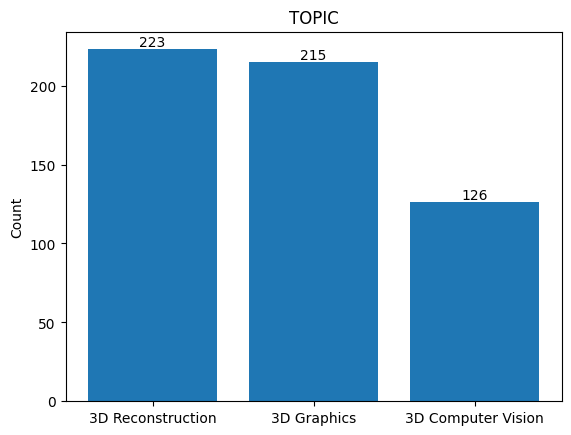

In [29]:
draw_histogram(is_3d_gen_df, 'topic')